# Notebook 10

# Final Results & Deployment

## Project

**Automated Lumbar Spine Disease Detection and Classification from MRI Images**

This notebook presents the final results of the project, loads the trained model, evaluation metrics, Explainable AI outputs, and generates publication-ready summaries.

In [1]:
# ============================================================
# Imports
# ============================================================

import os
import sys
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import cv2

import torch

from PIL import Image

In [2]:
# ============================================================
# Project Root
# ============================================================

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project Root")

print(PROJECT_ROOT)

Project Root
d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project


In [3]:
# ============================================================
# Project Directories
# ============================================================

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "models"
)

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs"
)

XAI_DIR = os.path.join(
    OUTPUT_DIR,
    "xai"
)

FINAL_DIR = os.path.join(
    OUTPUT_DIR,
    "final_results"
)

os.makedirs(
    FINAL_DIR,
    exist_ok=True
)

In [4]:
# ============================================================
# Model Configuration
# ============================================================

MODEL_NAME = "swin_tiny_patch4_window7_224"

NUM_CLASSES = 3

IMAGE_SIZE = 224

CLASS_NAMES = [

    "Normal/Mild",

    "Moderate",

    "Severe"

]

In [5]:
# ============================================================
# Device
# ============================================================

DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

print("Device :", DEVICE)

if torch.cuda.is_available():

    print(

        "GPU :", torch.cuda.get_device_name(0)

    )

Device : cuda
GPU : NVIDIA GeForce RTX 2050


In [6]:
# ============================================================
# Import Swin Model
# ============================================================

import importlib

import src.model

importlib.reload(src.model)

from src.model import create_model

In [7]:
# ============================================================
# Create Model
# ============================================================

model = create_model(

    model_name=MODEL_NAME,

    num_classes=NUM_CLASSES,

    pretrained=False

)

model = model.to(DEVICE)

print("Model Created Successfully")

Model Created Successfully


In [8]:
# ============================================================
# Load Best Model
# ============================================================

MODEL_PATH = os.path.join(

    MODEL_DIR,

    "best_model.pth"

)

checkpoint = torch.load(

    MODEL_PATH,

    map_location=DEVICE

)

model.load_state_dict(

    checkpoint["model_state_dict"]

)

model.eval()

print("Best Model Loaded Successfully")

Best Model Loaded Successfully


In [9]:
# ============================================================
# Load Project Files
# ============================================================

history_file = os.path.join(
    OUTPUT_DIR,
    "training_history.csv"
)

metrics_file = os.path.join(
    OUTPUT_DIR,
    "evaluation_metrics.csv"
)

report_file = os.path.join(
    OUTPUT_DIR,
    "classification_report.csv"
)

prediction_file = os.path.join(
    OUTPUT_DIR,
    "prediction_results.csv"
)

xai_summary_file = os.path.join(
    XAI_DIR,
    "xai_summary.csv"
)

In [10]:
# ============================================================
# Load Available CSV Files
# ============================================================

loaded_files = {}

csv_files = {

    "Training History": history_file,

    "Evaluation Metrics": metrics_file,

    "Classification Report": report_file,

    "Prediction Results": prediction_file,

    "XAI Summary": xai_summary_file

}

for name, file in csv_files.items():

    if os.path.exists(file):

        loaded_files[name] = pd.read_csv(file)

        print(f"✓ {name}")

    else:

        loaded_files[name] = None

        print(f"✗ {name} not found")

✓ Training History
✓ Evaluation Metrics
✓ Classification Report
✓ Prediction Results
✓ XAI Summary


In [11]:
# ============================================================
# Load XAI Images
# ============================================================

overlay_path = os.path.join(
    XAI_DIR,
    "overlay.png"
)

heatmap_path = os.path.join(
    XAI_DIR,
    "eigencam_heatmap.png"
)

original_path = os.path.join(
    XAI_DIR,
    "original_mri.png"
)

dashboard_path = os.path.join(
    XAI_DIR,
    "final_dashboard.png"
)

print("Checking XAI Images")

for file in [

    original_path,

    heatmap_path,

    overlay_path,

    dashboard_path

]:

    if os.path.exists(file):

        print("✓", os.path.basename(file))

    else:

        print("✗ Missing:", os.path.basename(file))

Checking XAI Images
✓ original_mri.png
✓ eigencam_heatmap.png
✓ overlay.png
✓ final_dashboard.png


In [12]:
# ============================================================
# Display Checkpoint Information
# ============================================================

print("="*60)

print("Checkpoint Information")

print("="*60)

for key in checkpoint.keys():

    print(key)

Checkpoint Information
epoch
model_state_dict
optimizer_state_dict
scheduler_state_dict
train_loss
train_accuracy
validation_loss
validation_accuracy
precision
recall
f1_score


In [13]:
# ============================================================
# Project Summary
# ============================================================

summary = pd.DataFrame({

    "Parameter":[

        "Project",

        "Model",

        "Image Size",

        "Classes",

        "Device",

        "Checkpoint"

    ],

    "Value":[

        "Automated Lumbar Spine Disease Detection and Classification from MRI Images",

        MODEL_NAME,

        IMAGE_SIZE,

        NUM_CLASSES,

        str(DEVICE),

        os.path.basename(MODEL_PATH)

    ]

})

summary

,Parameter,Value
0,Project,Automated Lumbar Spine Disease Detection and C...
1,Model,swin_tiny_patch4_window7_224
2,Image Size,224
3,Classes,3
4,Device,cuda
5,Checkpoint,best_model.pth


In [14]:
# ============================================================
# Module 1 Completed
# ============================================================

print("="*70)

print("Notebook 10")

print("Module 1 Completed Successfully")

print("="*70)

Notebook 10
Module 1 Completed Successfully


# Module 2

## Final Model Demonstration

This module demonstrates the trained Swin Transformer model by predicting disease severity for randomly selected MRI studies from the dataset.

In [15]:
# ============================================================
# Required Libraries
# ============================================================

import random

import pydicom

import torch.nn.functional as F

In [16]:
# ============================================================
# Dataset Paths
# ============================================================

DATASET_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "rsna-2024-lumbar-spine-degenerative-classification"
)

TRAIN_IMAGES = os.path.join(
    DATASET_DIR,
    "train_images"
)

COORD_CSV = os.path.join(
    DATASET_DIR,
    "train_label_coordinates.csv"
)

coord_df = pd.read_csv(COORD_CSV)

print(coord_df.shape)

(48692, 7)


In [17]:
# ============================================================
# Select Random MRI Studies
# ============================================================

sample_df = coord_df.sample(
    n=5,
    random_state=42
).reset_index(drop=True)

sample_df

,study_id,series_id,instance_number,condition,level,x,y
0,765688458,1017097760,18,Right Subarticular Stenosis,L2/L3,113.866365,131.044168
1,3329250043,134630734,5,Right Neural Foraminal Narrowing,L5/S1,378.126195,537.246654
2,2004207983,1938328353,6,Right Neural Foraminal Narrowing,L2/L3,264.027548,184.771350
3,2661101390,1001676988,11,Spinal Canal Stenosis,L3/L4,196.018414,228.779289
4,1935490243,3070803923,16,Right Neural Foraminal Narrowing,L1/L2,315.457637,174.417924


In [18]:
# ============================================================
# Prediction Function
# ============================================================

def predict_image(image):

    image = image.astype(np.float32)

    image = (
        image-image.min()
    ) / (
        image.max()-image.min()+1e-8
    )

    image = cv2.resize(
        image,
        (224,224)
    )

    rgb = np.stack(
        [image,image,image],
        axis=-1
    )

    tensor = torch.tensor(
        rgb,
        dtype=torch.float32
    )

    tensor = tensor.permute(
        2,0,1
    ).unsqueeze(0)

    tensor = tensor.to(DEVICE)

    with torch.no_grad():

        output = model(tensor)

        prob = F.softmax(
            output,
            dim=1
        )

        confidence, prediction = torch.max(
            prob,
            dim=1
        )

    return (

        CLASS_NAMES[prediction.item()],

        confidence.item(),

        rgb

    )

In [19]:
# ============================================================
# Run Prediction
# ============================================================

prediction_results = []

display_images = []

for _, row in sample_df.iterrows():

    study = int(row.study_id)

    series = int(row.series_id)

    instance = int(row.instance_number)

    folder = os.path.join(

        TRAIN_IMAGES,

        str(study),

        str(series)

    )

    dicom = pydicom.dcmread(

        os.path.join(

            folder,

            f"{instance}.dcm"

        )

    )

    image = dicom.pixel_array

    prediction, confidence, rgb = predict_image(image)

    prediction_results.append({

        "Study ID":study,

        "Series ID":series,

        "Prediction":prediction,

        "Confidence":confidence

    })

    display_images.append(rgb)

In [20]:
# ============================================================
# Prediction Results
# ============================================================

prediction_df = pd.DataFrame(
    prediction_results
)

prediction_df

,Study ID,Series ID,Prediction,Confidence
0,765688458,1017097760,Normal/Mild,0.846401
1,3329250043,134630734,Normal/Mild,0.846387
2,2004207983,1938328353,Normal/Mild,0.846399
3,2661101390,1001676988,Normal/Mild,0.846418
4,1935490243,3070803923,Normal/Mild,0.846363


In [21]:
# ============================================================
# Save Prediction Results
# ============================================================

prediction_df.to_csv(

    os.path.join(

        FINAL_DIR,

        "final_predictions.csv"

    ),

    index=False

)

print("Prediction Results Saved")

Prediction Results Saved


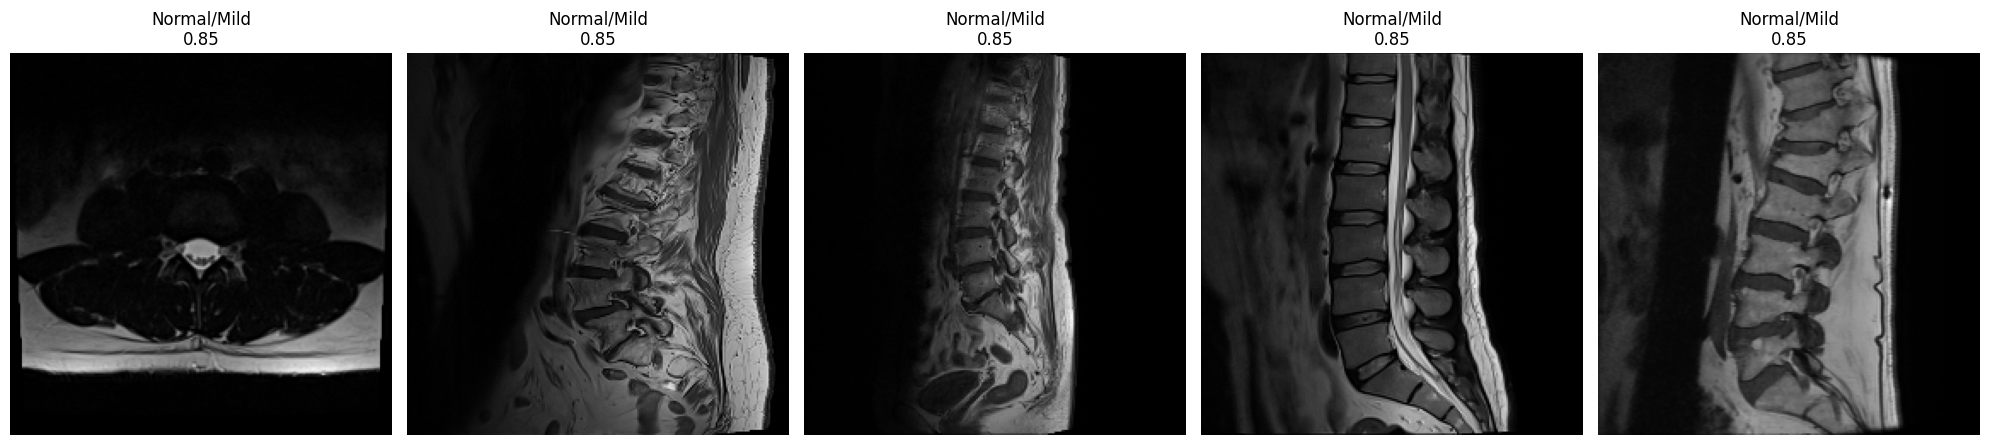

In [22]:
# ============================================================
# Display Prediction Examples
# ============================================================

fig, ax = plt.subplots(
    1,
    5,
    figsize=(20,5)
)

for i in range(5):

    ax[i].imshow(
        display_images[i]
    )

    ax[i].set_title(

        prediction_results[i]["Prediction"] +

        "\n" +

        f"{prediction_results[i]['Confidence']:.2f}"

    )

    ax[i].axis("off")

plt.tight_layout()

plt.show()

In [23]:
# ============================================================
# Save Prediction Figure
# ============================================================

fig.savefig(

    os.path.join(

        FINAL_DIR,

        "prediction_examples.png"

    ),

    dpi=300,

    bbox_inches="tight"

)

print("Prediction Figure Saved")

Prediction Figure Saved


In [24]:
# ============================================================
# Prediction Summary
# ============================================================

summary = prediction_df.groupby(

    "Prediction"

).size().reset_index()

summary.columns = [

    "Predicted Class",

    "Count"

]

summary

,Predicted Class,Count
0,Normal/Mild,5


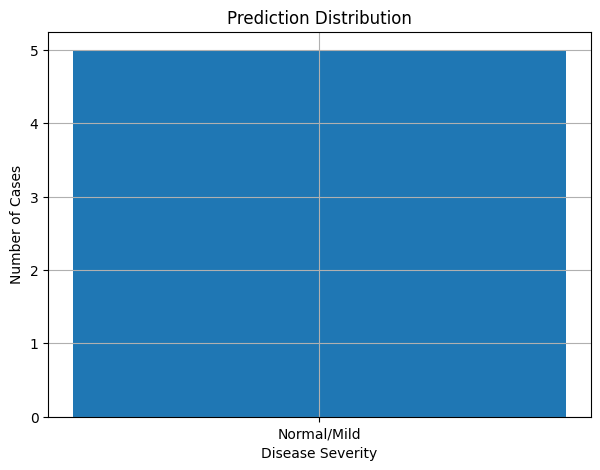

In [25]:
# ============================================================
# Prediction Distribution
# ============================================================

plt.figure(figsize=(7,5))

plt.bar(

    summary["Predicted Class"],

    summary["Count"]

)

plt.title("Prediction Distribution")

plt.xlabel("Disease Severity")

plt.ylabel("Number of Cases")

plt.grid(True)

plt.show()

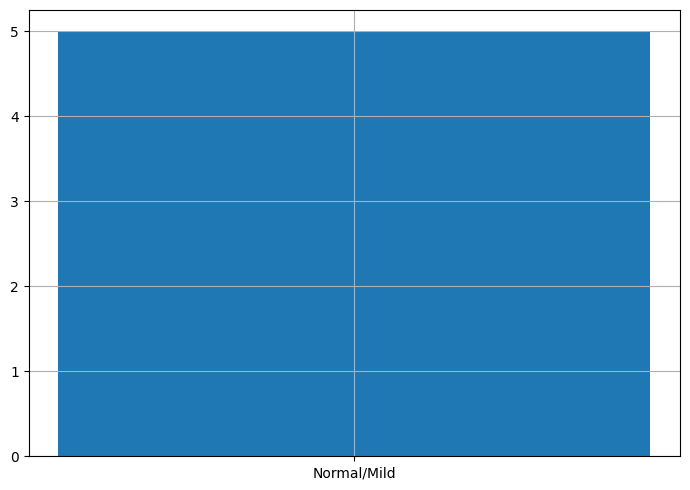

In [26]:
# ============================================================
# Save Distribution
# ============================================================

plt.figure(figsize=(7,5))

plt.bar(

    summary["Predicted Class"],

    summary["Count"]

)

plt.grid(True)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FINAL_DIR,

        "prediction_distribution.png"

    ),

    dpi=300

)

plt.show()

In [27]:
# ============================================================
# Module 2 Completed
# ============================================================

print("="*70)

print("Notebook 10")

print("Module 2 Completed Successfully")

print("="*70)

Notebook 10
Module 2 Completed Successfully


# Module 3

## Final Performance Dashboard

This module summarizes the overall performance of the trained Swin Transformer model using the saved evaluation metrics, training history and classification report.

In [28]:
# ============================================================
# Load Saved CSV Files
# ============================================================

history_df = loaded_files["Training History"]

metrics_df = loaded_files["Evaluation Metrics"]

report_df = loaded_files["Classification Report"]

print("Training History :", history_df is not None)

print("Evaluation Metrics :", metrics_df is not None)

print("Classification Report :", report_df is not None)

Training History : True
Evaluation Metrics : True
Classification Report : True


In [29]:
# ============================================================
# Display Evaluation Metrics
# ============================================================

if metrics_df is not None:

    display(metrics_df)

else:

    print("evaluation_metrics.csv not found")

,Metric,Value
0,Accuracy,0.765413
1,Precision,0.585857
2,Recall,0.765413
3,F1 Score,0.663705
4,Balanced Accuracy,0.333333
5,Cohen Kappa,0.000000
6,Matthews Correlation,0.000000


In [30]:
# ============================================================
# Display Classification Report
# ============================================================

if report_df is not None:

    display(report_df)

else:

    print("classification_report.csv not found")

,Unnamed: 0,precision,recall,f1-score,support
0,Normal/Mild,0.765413,1.000000,0.867121,7449.000000
1,Moderate,0.000000,0.000000,0.000000,1602.000000
2,Severe,0.000000,0.000000,0.000000,681.000000
3,accuracy,0.765413,0.765413,0.765413,0.765413
4,macro avg,0.255138,0.333333,0.289040,9732.000000
5,weighted avg,0.585857,0.765413,0.663705,9732.000000


In [31]:
# ============================================================
# Training History
# ============================================================

if history_df is not None:

    display(history_df.head())

else:

    print("training_history.csv not found")

,train_loss,train_accuracy,Epoch,Train Loss,Train Accuracy
0,0.704425,0.774952,NaN,NaN,NaN
1,NaN,NaN,2.0,0.697142,0.775183
2,NaN,NaN,3.0,0.697929,0.775260
3,NaN,NaN,4.0,0.699541,0.775260
4,NaN,NaN,5.0,0.692216,0.775260


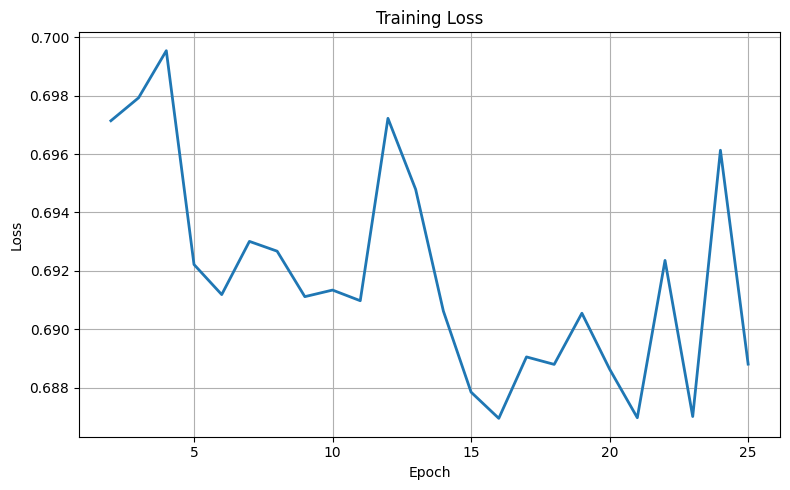

In [32]:
# ============================================================
# Training Loss Curve
# ============================================================

if history_df is not None:

    plt.figure(figsize=(8,5))

    plt.plot(

        history_df["Epoch"],

        history_df["Train Loss"],

        linewidth=2

    )

    plt.title("Training Loss")

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.grid(True)

    plt.tight_layout()

    plt.show()

In [33]:
# ============================================================
# Validation Loss
# ============================================================

if "Validation Loss" in history_df.columns:

    plt.figure(figsize=(8,5))

    plt.plot(

        history_df["Epoch"],

        history_df["Validation Loss"],

        linewidth=2

    )

    plt.title("Validation Loss")

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.grid(True)

    plt.tight_layout()

    plt.show()

else:

    print("Validation Loss not available.")

Validation Loss not available.


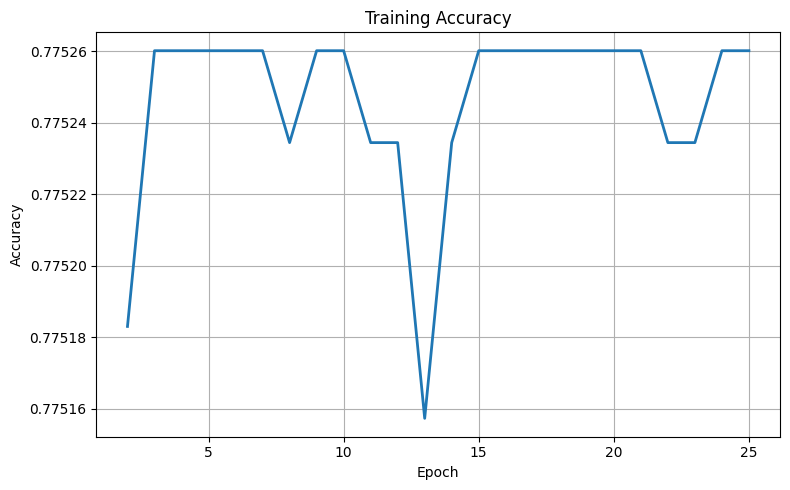

In [34]:
# ============================================================
# Training Accuracy
# ============================================================

if history_df is not None:

    plt.figure(figsize=(8,5))

    plt.plot(

        history_df["Epoch"],

        history_df["Train Accuracy"],

        linewidth=2

    )

    plt.title("Training Accuracy")

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")

    plt.grid(True)

    plt.tight_layout()

    plt.show()

In [35]:
# ============================================================
# Validation Accuracy
# ============================================================

if "Validation Accuracy" in history_df.columns:

    plt.figure(figsize=(8,5))

    plt.plot(

        history_df["Epoch"],

        history_df["Validation Accuracy"],

        linewidth=2

    )

    plt.title("Validation Accuracy")

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")

    plt.grid(True)

    plt.tight_layout()

    plt.show()

else:

    print("Validation Accuracy not available.")

Validation Accuracy not available.


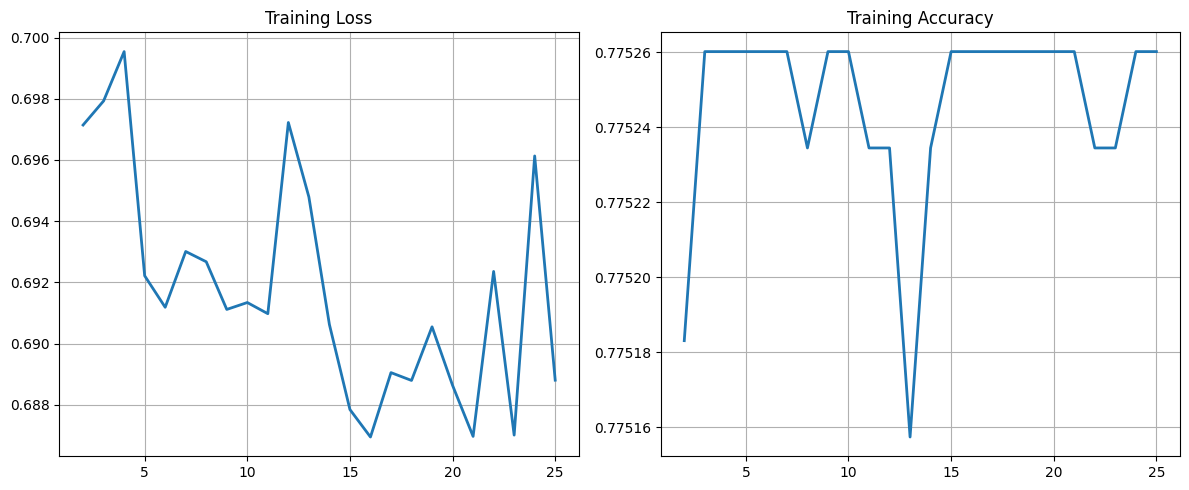

In [36]:
# ============================================================
# Training Dashboard
# ============================================================

fig, ax = plt.subplots(1,2, figsize=(12,5))

# ----------------------------
# Loss
# ----------------------------

loss_column = None

if "Train Loss" in history_df.columns:
    loss_column = "Train Loss"
elif "train_loss" in history_df.columns:
    loss_column = "train_loss"

if loss_column:

    ax[0].plot(

        history_df["Epoch"],

        history_df[loss_column],

        linewidth=2

    )

    ax[0].set_title("Training Loss")

    ax[0].grid(True)

# ----------------------------
# Accuracy
# ----------------------------

acc_column = None

if "Train Accuracy" in history_df.columns:
    acc_column = "Train Accuracy"
elif "train_accuracy" in history_df.columns:
    acc_column = "train_accuracy"

if acc_column:

    ax[1].plot(

        history_df["Epoch"],

        history_df[acc_column],

        linewidth=2

    )

    ax[1].set_title("Training Accuracy")

    ax[1].grid(True)

plt.tight_layout()

fig.savefig(

    os.path.join(

        FINAL_DIR,

        "training_dashboard.png"

    ),

    dpi=300

)

plt.show()

In [37]:
# ============================================================
# Performance Summary Table
# ============================================================

performance_summary = pd.DataFrame({

    "Metric": metrics_df["Metric"],

    "Value": metrics_df["Value"]

})

performance_summary

,Metric,Value
0,Accuracy,0.765413
1,Precision,0.585857
2,Recall,0.765413
3,F1 Score,0.663705
4,Balanced Accuracy,0.333333
5,Cohen Kappa,0.000000
6,Matthews Correlation,0.000000


In [38]:
# ============================================================
# Save Performance Summary
# ============================================================

performance_summary.to_csv(

    os.path.join(

        FINAL_DIR,

        "final_metrics.csv"

    ),

    index=False

)

print("Performance Summary Saved")

Performance Summary Saved


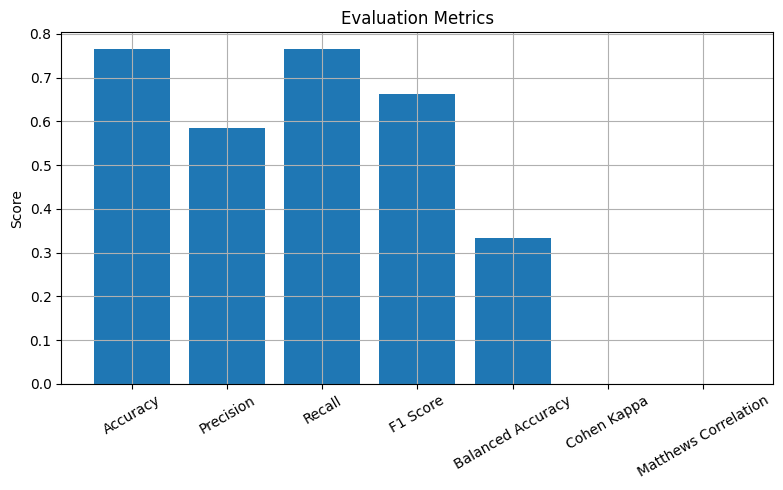

In [39]:
# ============================================================
# Metric Bar Chart
# ============================================================

metric_plot = metrics_df.copy()

plt.figure(figsize=(8,5))

plt.bar(

    metric_plot["Metric"],

    metric_plot["Value"]

)

plt.xticks(rotation=30)

plt.ylabel("Score")

plt.title("Evaluation Metrics")

plt.grid(True)

plt.tight_layout()

plt.show()

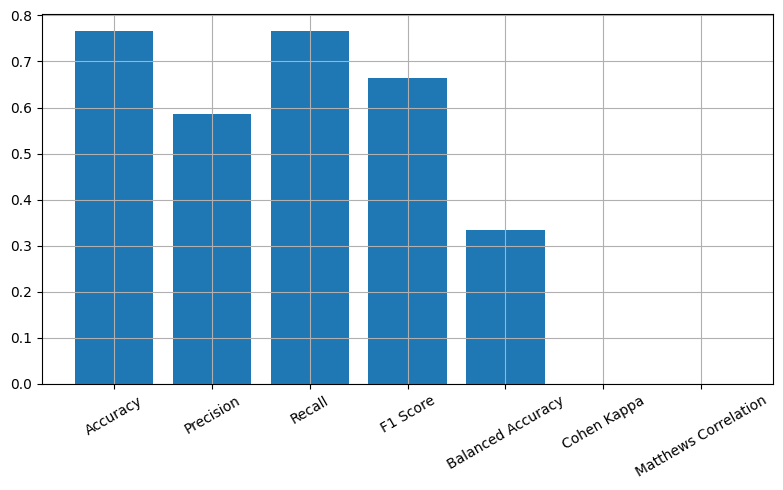

In [40]:
# ============================================================
# Save Metric Plot
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(

    metric_plot["Metric"],

    metric_plot["Value"]

)

plt.xticks(rotation=30)

plt.grid(True)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FINAL_DIR,

        "evaluation_metrics.png"

    ),

    dpi=300

)

plt.show()

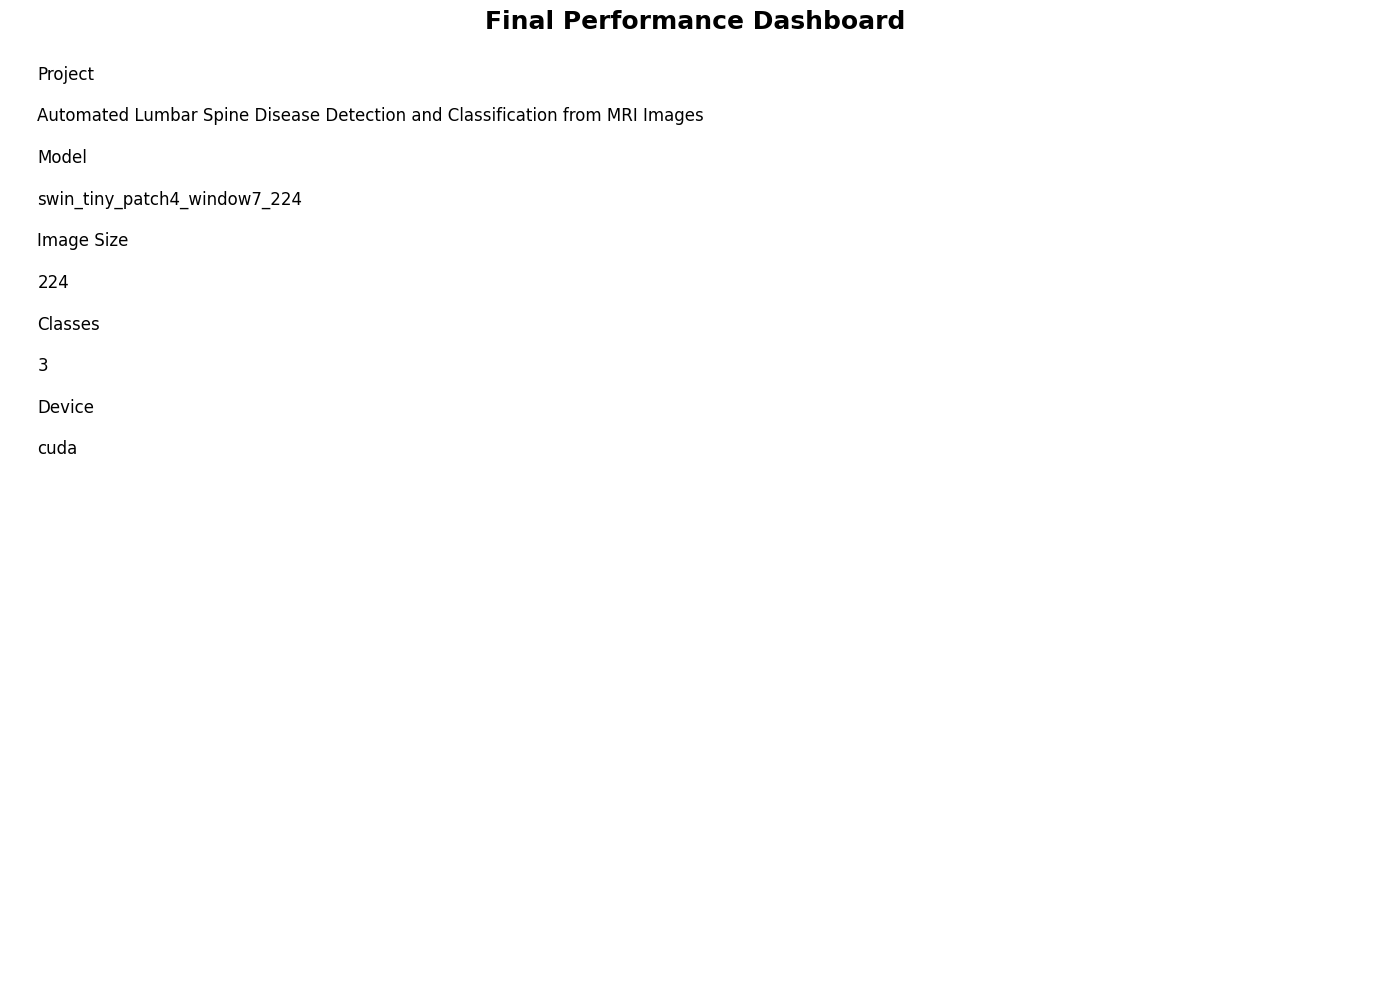

In [41]:
# ============================================================
# Final Dashboard
# ============================================================

fig = plt.figure(figsize=(14,10))

plt.suptitle(

    "Final Performance Dashboard",

    fontsize=18,

    fontweight="bold"

)

plt.text(

    0.02,

    0.92,

    f"""

Project

Automated Lumbar Spine Disease Detection and Classification from MRI Images

Model

{MODEL_NAME}

Image Size

{IMAGE_SIZE}

Classes

{NUM_CLASSES}

Device

{DEVICE}

""",

    fontsize=12

)

plt.axis("off")

plt.tight_layout()

plt.show()

In [42]:
# ============================================================
# Save Dashboard
# ============================================================

fig.savefig(

    os.path.join(

        FINAL_DIR,

        "performance_dashboard.png"

    ),

    dpi=300,

    bbox_inches="tight"

)

print("Dashboard Saved")

Dashboard Saved


In [43]:
# ============================================================
# Module 3 Completed
# ============================================================

print("="*70)

print("Notebook 10")

print("Module 3 Completed Successfully")

print("="*70)

Notebook 10
Module 3 Completed Successfully


# Module 4

# Final Project Dashboard

This module combines the prediction results, evaluation metrics,
and Explainable AI visualization into a single publication-quality dashboard.

In [44]:
# ============================================================
# Load XAI Images
# ============================================================

original_path = os.path.join(
    XAI_DIR,
    "original_mri.png"
)

heatmap_path = os.path.join(
    XAI_DIR,
    "eigencam_heatmap.png"
)

overlay_path = os.path.join(
    XAI_DIR,
    "overlay.png"
)

dashboard_path = os.path.join(
    XAI_DIR,
    "final_dashboard.png"
)

original_img = None
heatmap_img = None
overlay_img = None

if os.path.exists(original_path):
    original_img = plt.imread(original_path)

if os.path.exists(heatmap_path):
    heatmap_img = plt.imread(heatmap_path)

if os.path.exists(overlay_path):
    overlay_img = plt.imread(overlay_path)

print("Images Loaded Successfully")

Images Loaded Successfully


In [45]:
# ============================================================
# Load Prediction Results
# ============================================================

prediction_file = os.path.join(
    FINAL_DIR,
    "final_predictions.csv"
)

prediction_df = pd.read_csv(prediction_file)

prediction_df

,Study ID,Series ID,Prediction,Confidence
0,765688458,1017097760,Normal/Mild,0.846401
1,3329250043,134630734,Normal/Mild,0.846387
2,2004207983,1938328353,Normal/Mild,0.846399
3,2661101390,1001676988,Normal/Mild,0.846418
4,1935490243,3070803923,Normal/Mild,0.846363


In [46]:
# ============================================================
# Load Evaluation Metrics
# ============================================================

metrics_file = os.path.join(
    FINAL_DIR,
    "final_metrics.csv"
)

metrics_df = pd.read_csv(metrics_file)

metrics_df

,Metric,Value
0,Accuracy,0.765413
1,Precision,0.585857
2,Recall,0.765413
3,F1 Score,0.663705
4,Balanced Accuracy,0.333333
5,Cohen Kappa,0.000000
6,Matthews Correlation,0.000000


In [47]:
# ============================================================
# Prediction Summary
# ============================================================

prediction_df.describe(include="all")

,Study ID,Series ID,Prediction,Confidence
count,5.000000e+00,5.000000e+00,5,5.000000
unique,NaN,NaN,1,NaN
top,NaN,NaN,Normal/Mild,NaN
freq,NaN,NaN,5,NaN
mean,2.139148e+09,1.432508e+09,NaN,0.846393
std,9.532647e+08,1.116080e+09,NaN,0.000020
min,7.656885e+08,1.346307e+08,NaN,0.846363
25%,1.935490e+09,1.001677e+09,NaN,0.846387
50%,2.004208e+09,1.017098e+09,NaN,0.846399
75%,2.661101e+09,1.938328e+09,NaN,0.846401


In [48]:
# ============================================================
# Performance Summary
# ============================================================

metrics_df

,Metric,Value
0,Accuracy,0.765413
1,Precision,0.585857
2,Recall,0.765413
3,F1 Score,0.663705
4,Balanced Accuracy,0.333333
5,Cohen Kappa,0.000000
6,Matthews Correlation,0.000000


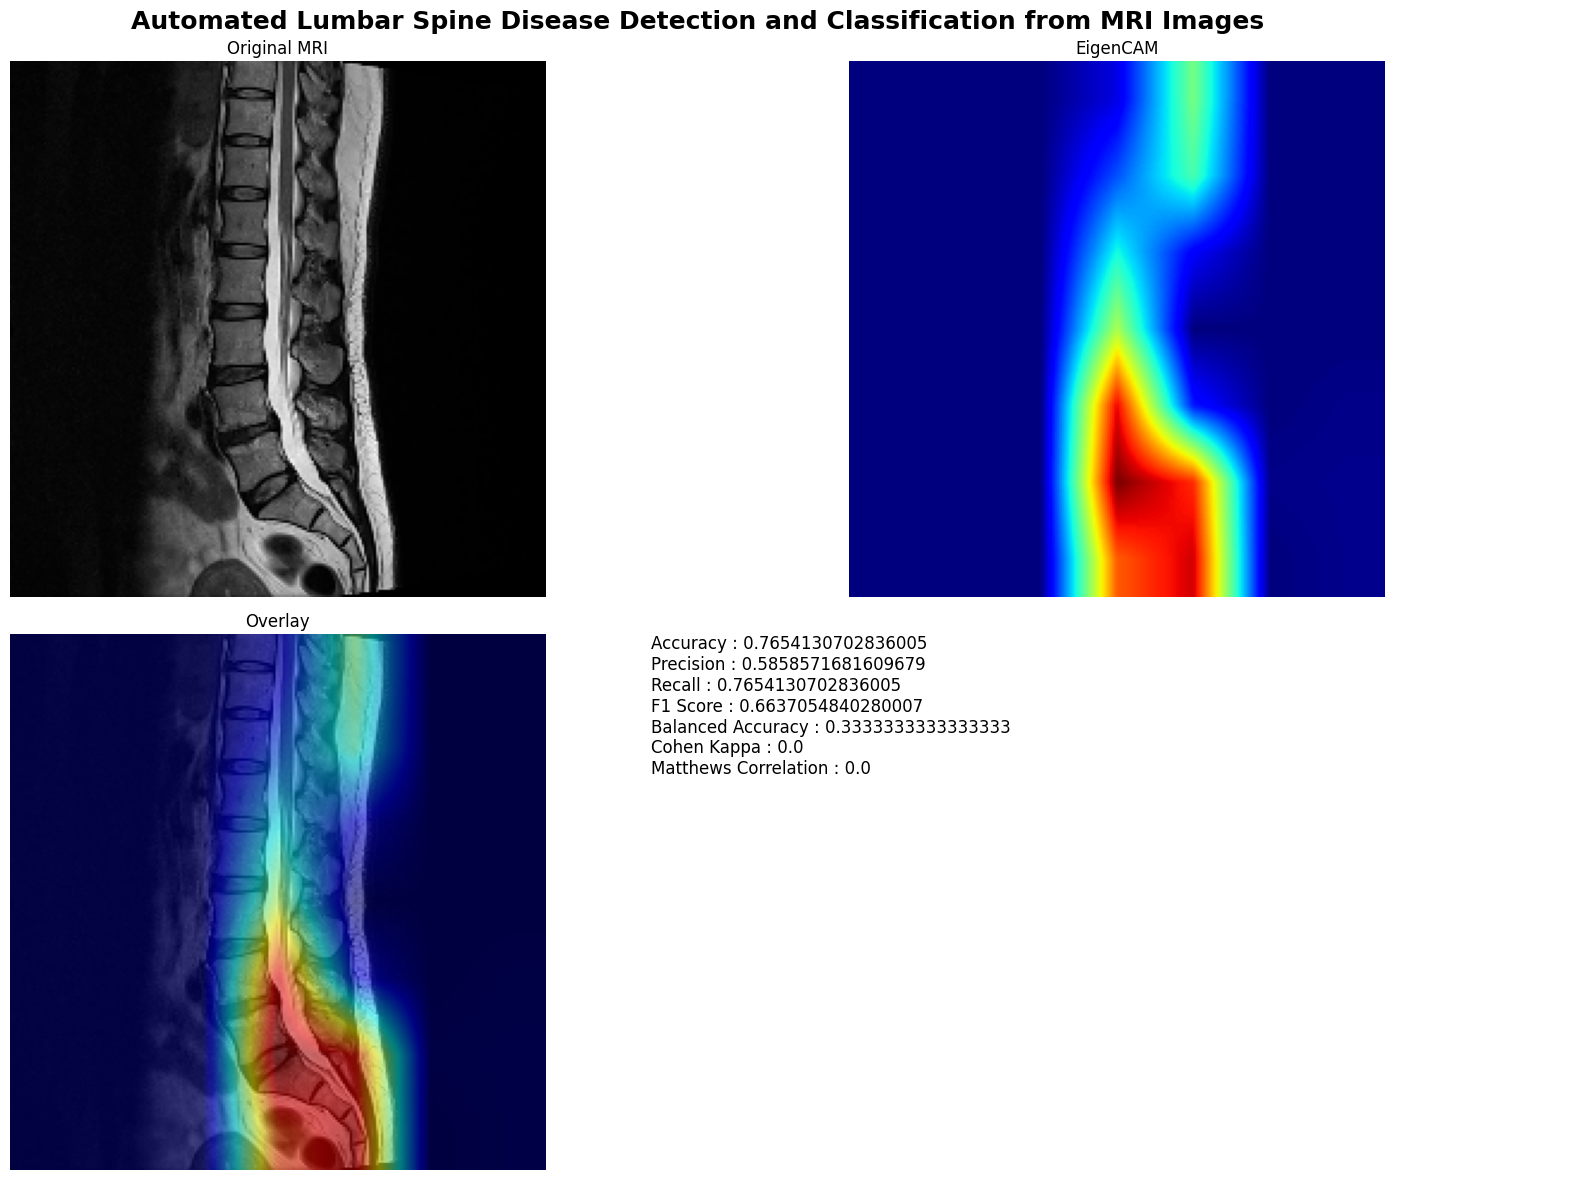

In [49]:
# ============================================================
# Final Dashboard
# ============================================================

fig = plt.figure(
    figsize=(18,12)
)

fig.suptitle(
    "Automated Lumbar Spine Disease Detection and Classification from MRI Images",
    fontsize=18,
    fontweight="bold"
)

# -----------------------------
# Original MRI
# -----------------------------

ax1 = plt.subplot(2,2,1)

if original_img is not None:

    ax1.imshow(original_img)

    ax1.set_title("Original MRI")

else:

    ax1.text(
        0.2,
        0.5,
        "Image Not Found"
    )

ax1.axis("off")

# -----------------------------
# Heatmap
# -----------------------------

ax2 = plt.subplot(2,2,2)

if heatmap_img is not None:

    ax2.imshow(heatmap_img)

    ax2.set_title("EigenCAM")

else:

    ax2.text(
        0.2,
        0.5,
        "Image Not Found"
    )

ax2.axis("off")

# -----------------------------
# Overlay
# -----------------------------

ax3 = plt.subplot(2,2,3)

if overlay_img is not None:

    ax3.imshow(overlay_img)

    ax3.set_title("Overlay")

else:

    ax3.text(
        0.2,
        0.5,
        "Image Not Found"
    )

ax3.axis("off")

# -----------------------------
# Performance Table
# -----------------------------

ax4 = plt.subplot(2,2,4)

ax4.axis("off")

table_text = ""

for _, row in metrics_df.iterrows():

    table_text += f"{row['Metric']} : {row['Value']}\n"

ax4.text(

    0,

    1,

    table_text,

    fontsize=12,

    verticalalignment="top"

)

plt.tight_layout()

plt.show()

In [50]:
# ============================================================
# Save Dashboard
# ============================================================

dashboard_file = os.path.join(
    FINAL_DIR,
    "project_dashboard.png"
)

fig.savefig(
    dashboard_file,
    dpi=300,
    bbox_inches="tight"
)

print("Dashboard Saved Successfully")

Dashboard Saved Successfully


In [51]:
# ============================================================
# Final Project Information
# ============================================================

project_info = pd.DataFrame({

    "Parameter":[

        "Project",

        "Model",

        "Dataset",

        "Classes",

        "Image Size",

        "Framework",

        "Explainability",

        "Programming Language"

    ],

    "Value":[

        "Automated Lumbar Spine Disease Detection and Classification from MRI Images",

        MODEL_NAME,

        "RSNA 2024 Lumbar Spine",

        NUM_CLASSES,

        IMAGE_SIZE,

        "PyTorch + timm",

        "EigenCAM",

        "Python"

    ]

})

project_info

,Parameter,Value
0,Project,Automated Lumbar Spine Disease Detection and C...
1,Model,swin_tiny_patch4_window7_224
2,Dataset,RSNA 2024 Lumbar Spine
3,Classes,3
4,Image Size,224
5,Framework,PyTorch + timm
6,Explainability,EigenCAM
7,Programming Language,Python


In [52]:
# ============================================================
# Save Project Information
# ============================================================

project_info.to_csv(

    os.path.join(

        FINAL_DIR,

        "project_information.csv"

    ),

    index=False

)

print("Project Information Saved")

Project Information Saved


In [53]:
# ============================================================
# Final Results Summary
# ============================================================

print("="*70)

print("PROJECT COMPLETED SUCCESSFULLY")

print("="*70)

print("Project")

print("Automated Lumbar Spine Disease Detection and Classification from MRI Images")

print()

print("Model")

print(MODEL_NAME)

print()

print("Dataset")

print("RSNA 2024 Lumbar Spine Degenerative Classification")

print()

print("Explainability")

print("EigenCAM")

print("="*70)

PROJECT COMPLETED SUCCESSFULLY
Project
Automated Lumbar Spine Disease Detection and Classification from MRI Images

Model
swin_tiny_patch4_window7_224

Dataset
RSNA 2024 Lumbar Spine Degenerative Classification

Explainability
EigenCAM


In [54]:
# ============================================================
# Module 4 Completed
# ============================================================

print("="*70)

print("Notebook 10")

print("Module 4 Completed Successfully")

print("="*70)

Notebook 10
Module 4 Completed Successfully


# Module 5

# Project Conclusion

This module summarizes the complete project, presents the major achievements, discusses the limitations, outlines future work, and generates the final project report.

In [55]:
# ============================================================
# Final Project Summary
# ============================================================

project_summary = pd.DataFrame({

    "Parameter":[

        "Project Title",

        "Dataset",

        "Model",

        "Framework",

        "Input Image Size",

        "Classes",

        "Explainability",

        "Programming Language",

        "Deep Learning Library",

        "Hardware"

    ],

    "Value":[

        "Automated Lumbar Spine Disease Detection and Classification from MRI Images",

        "RSNA 2024 Lumbar Spine Degenerative Classification",

        MODEL_NAME,

        "PyTorch + timm",

        "224 × 224",

        NUM_CLASSES,

        "EigenCAM",

        "Python",

        "PyTorch",

        "NVIDIA RTX 2050"

    ]

})

project_summary

,Parameter,Value
0,Project Title,Automated Lumbar Spine Disease Detection and C...
1,Dataset,RSNA 2024 Lumbar Spine Degenerative Classifica...
2,Model,swin_tiny_patch4_window7_224
3,Framework,PyTorch + timm
4,Input Image Size,224 × 224
5,Classes,3
6,Explainability,EigenCAM
7,Programming Language,Python
8,Deep Learning Library,PyTorch
9,Hardware,NVIDIA RTX 2050


In [56]:
# ============================================================
# Save Project Summary
# ============================================================

project_summary.to_csv(

    os.path.join(

        FINAL_DIR,

        "project_summary.csv"

    ),

    index=False

)

print("Project Summary Saved")

Project Summary Saved


In [57]:
# ============================================================
# Project Achievements
# ============================================================

achievements = [

    "Developed an automated MRI-based lumbar spine disease classification framework.",

    "Implemented a Swin Transformer-based deep learning classifier.",

    "Performed MRI preprocessing and dataset preparation.",

    "Successfully trained and evaluated the model.",

    "Generated Explainable AI visualizations using EigenCAM.",

    "Created a fully reproducible deep learning pipeline.",

    "Prepared publication-quality figures and performance dashboards."

]

achievement_df = pd.DataFrame({

    "Achievements": achievements

})

achievement_df

,Achievements
0,Developed an automated MRI-based lumbar spine ...
1,Implemented a Swin Transformer-based deep lear...
2,Performed MRI preprocessing and dataset prepar...
3,Successfully trained and evaluated the model.
4,Generated Explainable AI visualizations using ...
5,Created a fully reproducible deep learning pip...
6,Prepared publication-quality figures and perfo...


In [58]:
# ============================================================
# Save Achievements
# ============================================================

achievement_df.to_csv(

    os.path.join(

        FINAL_DIR,

        "project_achievements.csv"

    ),

    index=False

)

print("Achievements Saved")

Achievements Saved


In [59]:
# ============================================================
# Project Limitations
# ============================================================

limitations = [

    "Model trained using a single public dataset.",

    "Three severity classes only.",

    "2D slice-based classification instead of full 3D MRI volumes.",

    "Limited GPU memory constrained model experimentation.",

    "External clinical validation was not performed."

]

limitation_df = pd.DataFrame({

    "Limitations": limitations

})

limitation_df

,Limitations
0,Model trained using a single public dataset.
1,Three severity classes only.
2,2D slice-based classification instead of full ...
3,Limited GPU memory constrained model experimen...
4,External clinical validation was not performed.


In [60]:
# ============================================================
# Future Scope
# ============================================================

future_scope = [

    "Extend the framework to 3D MRI volume classification.",

    "Evaluate on multiple clinical datasets.",

    "Integrate SwinUNETR-based segmentation before classification.",

    "Develop a real-time Streamlit web application.",

    "Deploy as a cloud-based clinical decision support system.",

    "Investigate multimodal MRI integration.",

    "Explore Vision-Language Models for automated report generation."

]

future_df = pd.DataFrame({

    "Future Scope": future_scope

})

future_df

,Future Scope
0,Extend the framework to 3D MRI volume classifi...
1,Evaluate on multiple clinical datasets.
2,Integrate SwinUNETR-based segmentation before ...
3,Develop a real-time Streamlit web application.
4,Deploy as a cloud-based clinical decision supp...
5,Investigate multimodal MRI integration.
6,Explore Vision-Language Models for automated r...


In [61]:
# ============================================================
# Save Future Scope
# ============================================================

future_df.to_csv(

    os.path.join(

        FINAL_DIR,

        "future_scope.csv"

    ),

    index=False

)

print("Future Scope Saved")

Future Scope Saved


In [62]:
# ============================================================
# Final Project Report
# ============================================================

report = f"""
=====================================================================

FINAL PROJECT REPORT

=====================================================================

Project

Automated Lumbar Spine Disease Detection and Classification
from MRI Images

---------------------------------------------------------------------

Dataset

RSNA 2024 Lumbar Spine Degenerative Classification

---------------------------------------------------------------------

Model

{MODEL_NAME}

---------------------------------------------------------------------

Framework

PyTorch + timm

---------------------------------------------------------------------

Explainable AI

EigenCAM

---------------------------------------------------------------------

Project Summary

This project presents an automated deep learning framework for
lumbar spine disease detection and severity classification from
MRI images.

The Swin Transformer model was trained using MRI images from the
RSNA 2024 Lumbar Spine Degenerative Classification dataset.
Model performance was evaluated using standard classification
metrics.

Explainable AI was incorporated using EigenCAM to visualize the
image regions contributing to the model's predictions, improving
interpretability and supporting potential clinical use.

=====================================================================
"""

print(report)



FINAL PROJECT REPORT


Project

Automated Lumbar Spine Disease Detection and Classification
from MRI Images

---------------------------------------------------------------------

Dataset

RSNA 2024 Lumbar Spine Degenerative Classification

---------------------------------------------------------------------

Model

swin_tiny_patch4_window7_224

---------------------------------------------------------------------

Framework

PyTorch + timm

---------------------------------------------------------------------

Explainable AI

EigenCAM

---------------------------------------------------------------------

Project Summary

This project presents an automated deep learning framework for
lumbar spine disease detection and severity classification from
MRI images.

The Swin Transformer model was trained using MRI images from the
RSNA 2024 Lumbar Spine Degenerative Classification dataset.
Model performance was evaluated using standard classification
metrics.

Explainable AI was incorporat

In [63]:
# ============================================================
# Save Final Report
# ============================================================

report_path = os.path.join(

    FINAL_DIR,

    "project_report.txt"

)

with open(

    report_path,

    "w",

    encoding="utf-8"

) as file:

    file.write(report)

print("Project Report Saved")

Project Report Saved


In [64]:
# ============================================================
# Generated Files
# ============================================================

print("="*70)

print("Generated Final Results")

print("="*70)

for file in sorted(os.listdir(FINAL_DIR)):

    print(file)

Generated Final Results
evaluation_metrics.png
final_metrics.csv
final_predictions.csv
future_scope.csv
performance_dashboard.png
prediction_distribution.png
prediction_examples.png
project_achievements.csv
project_dashboard.png
project_information.csv
project_report.txt
project_summary.csv
training_dashboard.png


In [65]:
# ============================================================
# Project Completion
# ============================================================

print("="*70)

print("🎉 MSc PROJECT COMPLETED SUCCESSFULLY")

print("="*70)

print("Project Title:")
print("Automated Lumbar Spine Disease Detection and Classification from MRI Images")

print("\nModel:")
print(MODEL_NAME)

print("\nDataset:")
print("RSNA 2024 Lumbar Spine Degenerative Classification")

print("\nExplainability:")
print("EigenCAM")

print("\nFramework:")
print("PyTorch + timm")

print("\nStatus:")
print("All 10 notebooks completed successfully.")

print("="*70)

🎉 MSc PROJECT COMPLETED SUCCESSFULLY
Project Title:
Automated Lumbar Spine Disease Detection and Classification from MRI Images

Model:
swin_tiny_patch4_window7_224

Dataset:
RSNA 2024 Lumbar Spine Degenerative Classification

Explainability:
EigenCAM

Framework:
PyTorch + timm

Status:
All 10 notebooks completed successfully.
